MODELO DE REGRESIÓN LINEAL, FUENTE DE DATOS: 2014-15 Home Sales in king 
County , WA
Variable objetivo: price
Variables predictorias: bedrooms, bathrooms, sqft_living, ,sqft_lot, floors

In [89]:
import sys
print(sys.executable)

C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


In [90]:
import pandas
print(pandas.__version__)


2.3.3


In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [92]:
import os
print(os.getcwd())


c:\Users\User\Desktop\Introduccion a machine Learning\Semana 4 . Herramientas de recoleción de datos\Proyecto chicos


In [93]:
import os

ruta_archivo = r"C:\Users\User\Desktop\Introduccion a machine Learning\Semana 4 . Herramientas de recoleción de datos\Proyecto chicos\kingcounty\kingcounty\kc_house_data.csv"
df = pd.read_csv(ruta_archivo)
df.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [95]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [96]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [97]:
datos = df[["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors"]].copy()

In [98]:
datos.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors
0,221900.0,3,1.00,1180,5650,1.0
1,538000.0,3,2.25,2570,7242,2.0
2,180000.0,2,1.00,770,10000,1.0
3,604000.0,4,3.00,1960,5000,1.0
4,510000.0,3,2.00,1680,8080,1.0


<h16>El comando datos.corr() calcula la matriz de correlación de Pearson entre las variables numéricas de tu DataFrame. Mide la fuerza y dirección de la relación lineal entre cada par de variables en un rango de -1 a 1<h16>


<h16>1.0: Correlación positiva perfecta (si una sube, la otra sube en la misma proporción). <h16>  

<h16>0.0: Sin correlación lineal.<h16> 

<h16>-1.0: Correlación negativa perfecta (si una sube, la otra baja).<h16>

In [99]:
datos.corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors
price,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794
bedrooms,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429
bathrooms,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653
sqft_living,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949
sqft_lot,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201
floors,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000


In [100]:
X = datos[["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors"]]
y = datos["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


<h8>test_size=0.2: Reserva el 20% de los datos para prueba (X_test, y_test) y utiliza el 80% restante para entrenamiento (X_train, y_train).<h8>

In [101]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 174809.61308234915
MSE: 74027479379.26872
RMSE: 272079.91359023313
R²: 0.5103248491507578


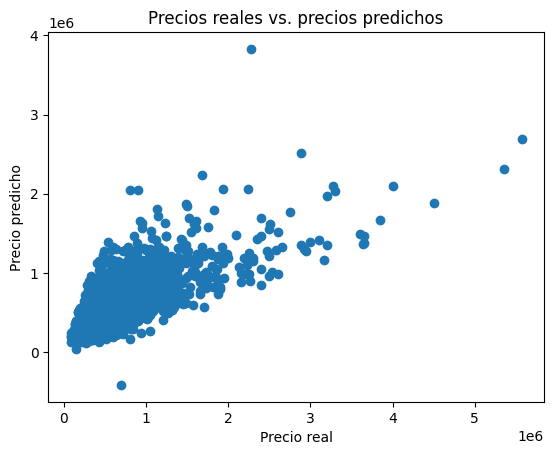

In [102]:
plt.scatter(y_test, y_pred)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Precios reales vs. precios predichos")
plt.show()

<h8>Este codigo es con IA me ayuda a ver visualmente mejor los graficos y aprender un poco mas de programacion <h8>

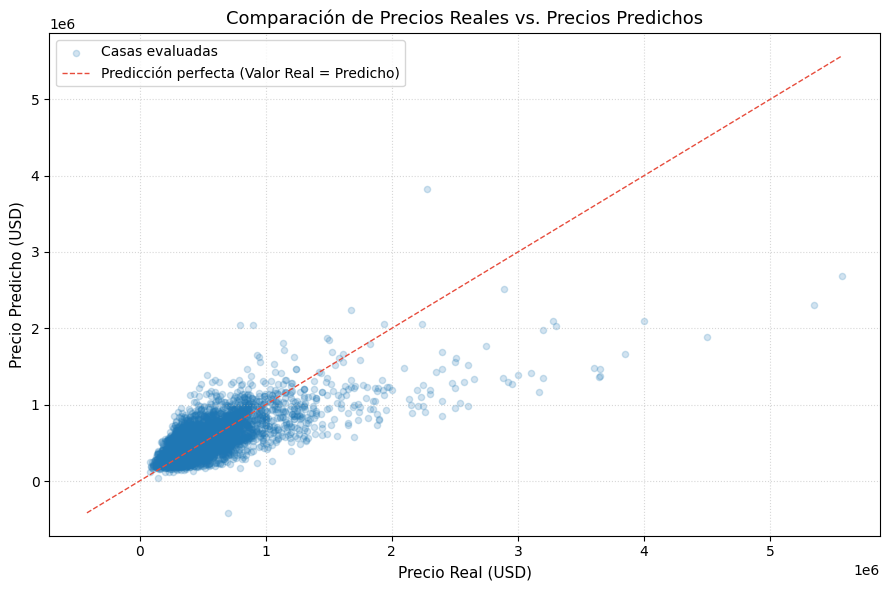

In [103]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir tamaño de la figura
plt.figure(figsize=(9, 6))

# 2. Gráfica de dispersión con puntos más pequeños y transparencia
plt.scatter(
    y_test, 
    y_pred, 
    s=20,                 # Tamaños de punto reducidos para reducir la superposición
    alpha=0.2,           # Transparencia para identificar zonas de alta densidad
    color="#1f77b4", 
    label="Casas evaluadas"
)

# 3. Línea diagonal de referencia ideal (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color="#e74c3c", 
    linestyle="--", 
    linewidth=1, 
    label="Predicción perfecta (Valor Real = Predicho)"
)

# 4. Títulos y etiquetas claras
plt.title("Comparación de Precios Reales vs. Precios Predichos", fontsize=13)
plt.xlabel("Precio Real (USD)", fontsize=11)
plt.ylabel("Precio Predicho (USD)", fontsize=11)

# 5. Formato de cuadrícula y leyenda
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()

plt.show()

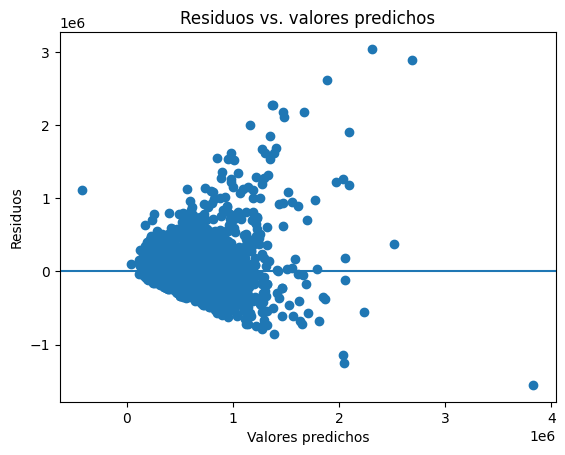

In [104]:
residuos = y_test - y_pred

plt.scatter(y_pred, residuos)
plt.axhline(0)
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs. valores predichos")
plt.show()

<h8>Este codigo es con ayuda de IA me ayuda a ver visualmente mejor los graficos entender los datos entre X,Y y aprender un poco mas de programacion <h8>

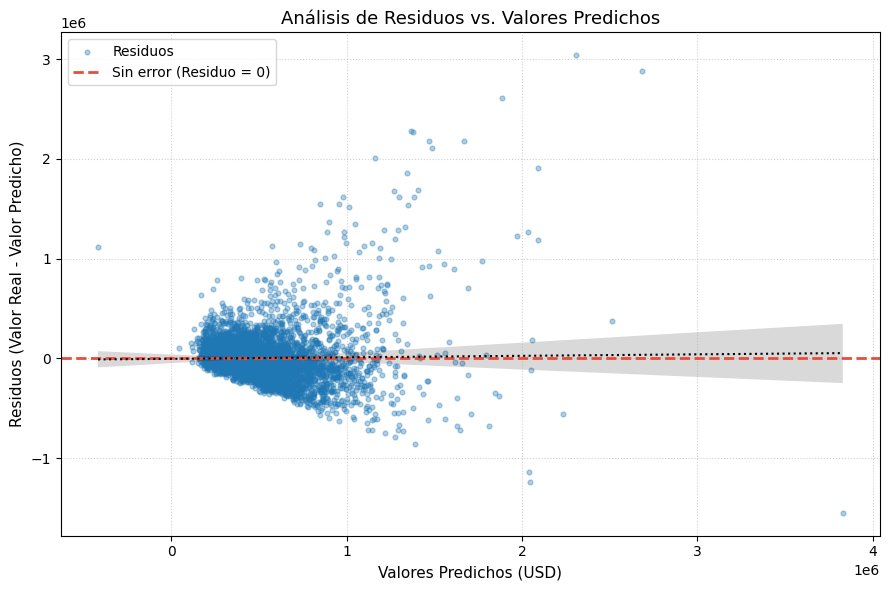

In [105]:
residuos = y_test - y_pred

# 2. Configurar el gráfico
plt.figure(figsize=(9, 6))

# Diagrama de dispersión de residuos
plt.scatter(
    y_pred, 
    residuos, 
    s=12,                 # Puntos más pequeños
    alpha=0.35,           # Transparencia para ver acumulación
    color="#1f77b4", 
    label="Residuos"
)

# Línea de referencia en cero (Error = 0)
plt.axhline(
    0, 
    color="#e74c3c", 
    linestyle="--", 
    linewidth=2, 
    label="Sin error (Residuo = 0)"
)

# Línea de tendencia de los residuos para detectar sesgos
sns.regplot(
    x=y_pred, 
    y=residuos, 
    scatter=False, 
    order=1, 
    color="black", 
    line_kws={"linewidth": 1.5, "linestyle": ":", "label": "Tendencia media"}
)

# Etiquetas y títulos
plt.title("Análisis de Residuos vs. Valores Predichos", fontsize=13)
plt.xlabel("Valores Predichos (USD)", fontsize=11)
plt.ylabel("Residuos (Valor Real - Valor Predicho)", fontsize=11)

plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()

plt.show()

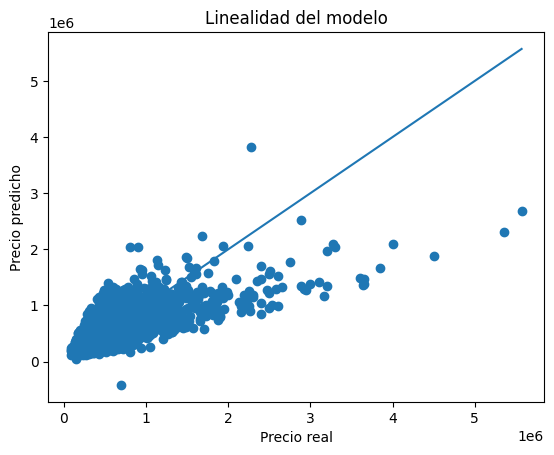

In [106]:
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Linealidad del modelo")
plt.show()

<h8>Este codigo es con ayuda de IA me ayuda a ver visualmente mejor los graficos entender los datos entre X,Y y aprender un poco mas de programacion <h8>

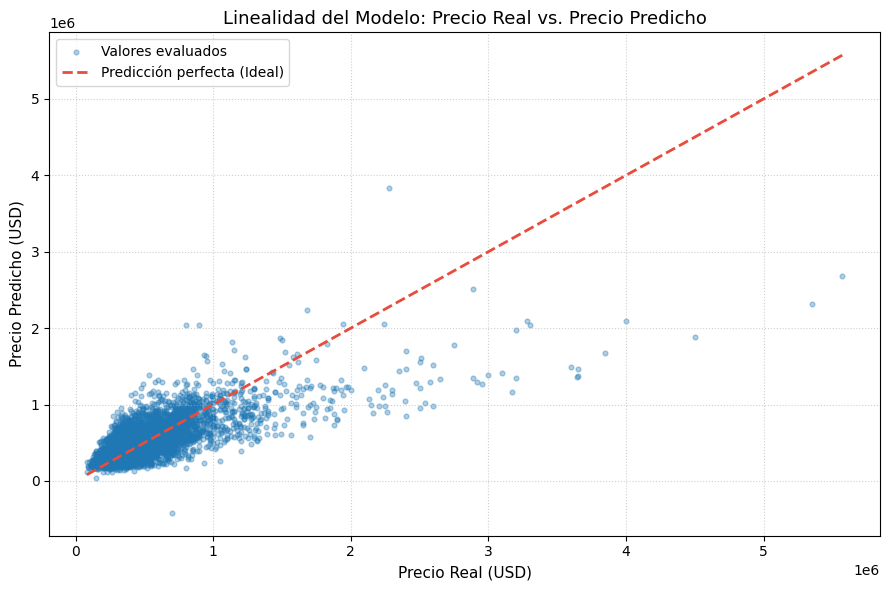

In [107]:
plt.figure(figsize=(9, 6))

# 2. Gráfico de dispersión con puntos más pequeños y transparencia
plt.scatter(
    y_test, 
    y_pred, 
    s=12,                 # Puntos más pequeños
    alpha=0.35,           # Transparencia para observar densidad de datos
    color="#1f77b4", 
    label="Valores evaluados"
)

# 3. Línea diagonal de referencia perfecta (y = x)
plt.plot(
    [y_test.min(), y_test.max()], 
    [y_test.min(), y_test.max()], 
    color="#e74c3c", 
    linestyle="--", 
    linewidth=2, 
    label="Predicción perfecta (Ideal)"
)

# 4. Títulos y etiquetas explicativas
plt.title("Linealidad del Modelo: Precio Real vs. Precio Predicho", fontsize=13)
plt.xlabel("Precio Real (USD)", fontsize=11)
plt.ylabel("Precio Predicho (USD)", fontsize=11)

# 5. Formato visual adicional
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()

plt.show()